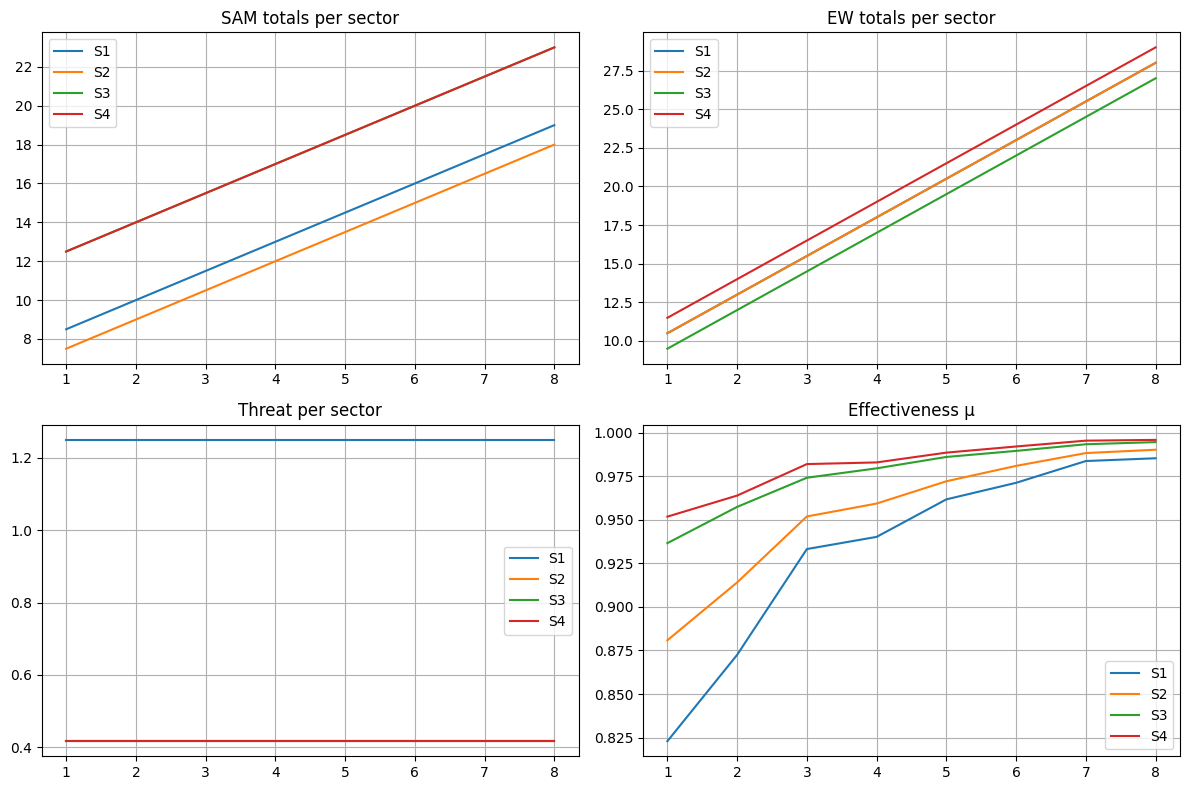

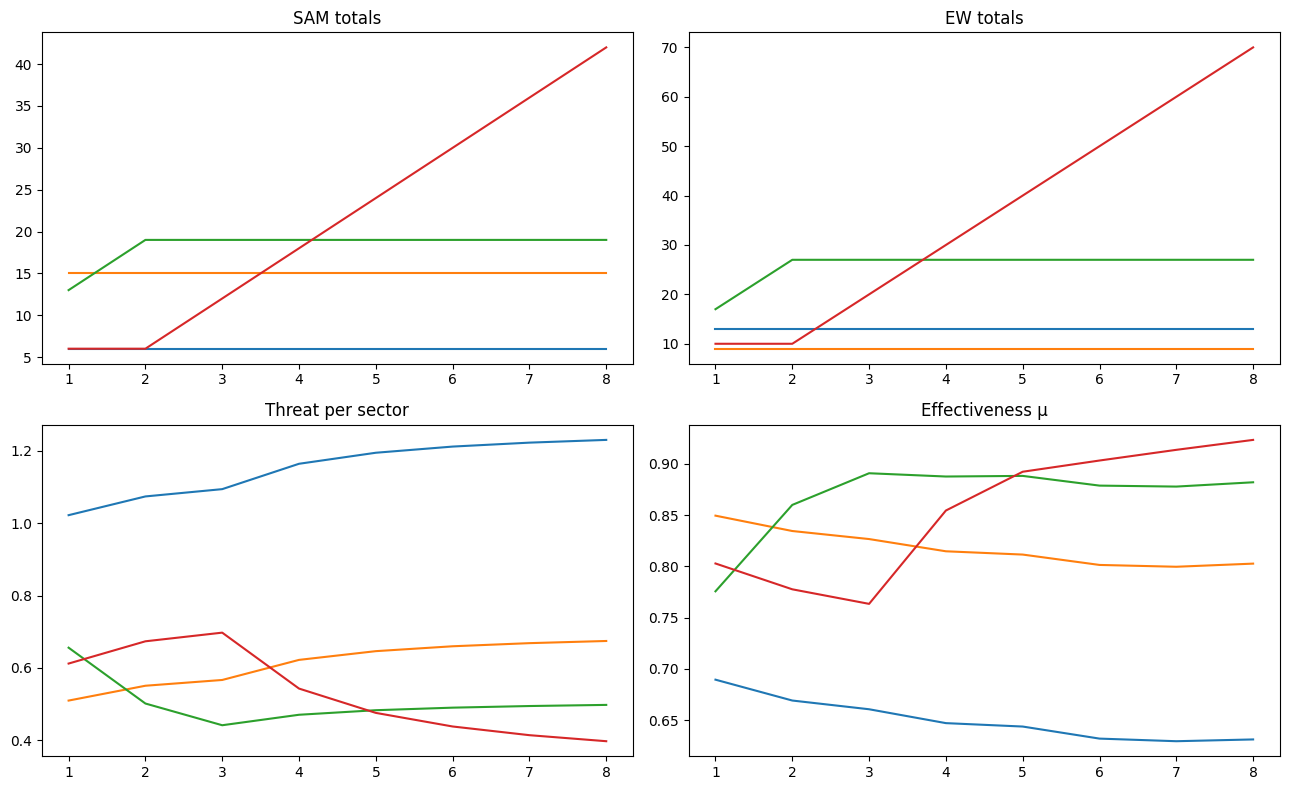

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ==============================
# CONFIG
# ==============================
S = 4
Ksam = 6
Kew = 10
Katt = 5
A = 5

T = 8
EPISODES = 1500
EVAL_RUNS = 150

EPS0 = 0.3
EPS_MIN = 0.05
EPS_DECAY = 0.995

LR = 0.08
GAMMA = 0.92

THREAT_BUDGET = 2.8

# ==============================
# PARAMETERS
# ==============================

SAM_W = np.linspace(0.4, 0.15, Ksam)
EW_W = np.linspace(0.25, 0.08, Kew)

SAM_VS = np.random.uniform(0.3, 1.0, (Ksam, Katt))
EW_VS = np.random.uniform(0.2, 0.9, (Kew, Katt))

RES_SAM = np.ones(Ksam)
RES_EW = np.ones(Kew)

# ==============================
# CORE MODEL (Different μ logic)
# ==============================

def simulate_wave(SAM, EW, TH):

    sam_score = np.zeros((S, Katt))
    ew_score = np.zeros((S, Katt))

    for i in range(Ksam):
        sam_score += np.tanh(0.3 * SAM[:, i:i+1]) * SAM_W[i] * SAM_VS[i]

    for j in range(Kew):
        ew_score += np.tanh(0.25 * EW[:, j:j+1]) * EW_W[j] * EW_VS[j]

    synergy = 0.15 * sam_score * ew_score
    defense = sam_score + ew_score + synergy

    mitigation = defense / (1 + defense)
    residual = TH * (1 - mitigation)

    damage = residual.sum(axis=1)
    mu = np.exp(-0.6 * damage)

    return np.clip(mu, 0, 1)


# ==============================
# RED MODEL (adaptive budget)
# ==============================

def red_action_to_threat(action, sector_strength):

    weights = np.ones(S)

    if action < 4:
        weights[action] = 2.5

    weights /= weights.sum()

    # adaptive pressure: attack weaker sectors harder
    inv_strength = 1 / (sector_strength + 1e-6)
    inv_strength /= inv_strength.sum()

    sec_mix = 0.6 * weights + 0.4 * inv_strength
    sec_mix /= sec_mix.sum()

    att_mix = np.random.dirichlet(np.ones(Katt))
    return (THREAT_BUDGET * sec_mix[:, None]) * att_mix[None, :]


# ==============================
# BLUE ACTION
# ==============================

def blue_apply(SAM, EW, action):

    SAM2 = SAM.copy()
    EW2 = EW.copy()

    if action < 4:
        SAM2[action] += RES_SAM
        EW2[action] += RES_EW
    else:
        for s in range(S):
            SAM2[s] += RES_SAM / S
            EW2[s] += RES_EW / S

    return SAM2, EW2


# ==============================
# RL UTILITIES
# ==============================

def encode(vec):
    bins = np.clip((vec * 3).astype(int), 0, 2)
    idx = 0
    for i, v in enumerate(bins):
        idx += v * (3 ** i)
    return idx


def epsilon_greedy(Q, s, eps):
    if random.random() < eps:
        return random.randint(0, A - 1)
    return np.argmax(Q[s])


# ==============================
# TRAJECTORY
# ==============================

@dataclass
class Traj:
    SAM_sum: np.ndarray
    EW_sum: np.ndarray
    TH: np.ndarray
    mu: np.ndarray
    risk: np.ndarray


# ==============================
# TRAIN
# ==============================

def train():

    n_states = 3 ** S
    QB = np.zeros((n_states, A))
    QR = np.zeros((n_states, A))

    eps = EPS0

    for ep in range(EPISODES):

        SAM = np.random.randint(0, 4, (S, Ksam)).astype(float)
        EW = np.random.randint(0, 3, (S, Kew)).astype(float)

        for t in range(T):

            strength = SAM.sum(axis=1) + EW.sum(axis=1)
            density = strength / (strength.sum() + 1e-6)

            sR = encode(density)
            aR = epsilon_greedy(QR, sR, eps)

            TH = red_action_to_threat(aR, strength)

            mu = simulate_wave(SAM, EW, TH)
            risk = 1 - mu

            sB = encode(risk)
            aB = epsilon_greedy(QB, sB, eps)

            SAM2, EW2 = blue_apply(SAM, EW, aB)
            mu2 = simulate_wave(SAM2, EW2, TH)

            load = SAM2.sum() + EW2.sum()

            rB = 1.2 * mu2.mean() - 0.03 * load - 0.8 * (1 - mu2.mean())
            rR = 1 - mu2.mean()

            sB2 = encode(1 - mu2)
            sR2 = encode((SAM2.sum(axis=1) + EW2.sum(axis=1)))

            QB[sB, aB] += LR * (rB + GAMMA * np.max(QB[sB2]) - QB[sB, aB])
            QR[sR, aR] += LR * (rR + GAMMA * np.max(QR[sR2]) - QR[sR, aR])

            SAM, EW = SAM2, EW2

        eps = max(EPS_MIN, eps * EPS_DECAY)

    return QB, QR


# ==============================
# EVALUATION
# ==============================

def run_episode(QB, QR):

    SAM = np.random.randint(0, 4, (S, Ksam)).astype(float)
    EW = np.random.randint(0, 3, (S, Kew)).astype(float)

    SAM_hist = []
    EW_hist = []
    TH_hist = []
    mu_hist = []
    risk_hist = []

    for t in range(T):

        strength = SAM.sum(axis=1) + EW.sum(axis=1)
        sR = encode(strength)
        aR = np.argmax(QR[sR])

        TH = red_action_to_threat(aR, strength)
        mu = simulate_wave(SAM, EW, TH)

        sB = encode(1 - mu)
        aB = np.argmax(QB[sB])

        SAM, EW = blue_apply(SAM, EW, aB)

        SAM_hist.append(SAM.sum(axis=1))
        EW_hist.append(EW.sum(axis=1))
        TH_hist.append(TH.sum(axis=1))
        mu_hist.append(mu)
        risk_hist.append(1 - mu)

    return Traj(
        np.array(SAM_hist),
        np.array(EW_hist),
        np.array(TH_hist),
        np.array(mu_hist),
        np.array(risk_hist),
    )


def plot_results(traj):

    t = np.arange(1, T + 1)

    plt.figure(figsize=(13,8))

    plt.subplot(2,2,1)
    for s in range(S):
        plt.plot(t, traj.SAM_sum[:,s])
    plt.title("SAM totals")

    plt.subplot(2,2,2)
    for s in range(S):
        plt.plot(t, traj.EW_sum[:,s])
    plt.title("EW totals")

    plt.subplot(2,2,3)
    for s in range(S):
        plt.plot(t, traj.TH[:,s])
    plt.title("Threat per sector")

    plt.subplot(2,2,4)
    for s in range(S):
        plt.plot(t, traj.mu[:,s])
    plt.title("Effectiveness μ")

    plt.tight_layout()
    plt.show()


# ==============================
# MAIN
# ==============================

if __name__ == "__main__":

    QB, QR = train()
    traj = run_episode(QB, QR)
    plot_results(traj)